# 03 - Análise Exploratória de Dados (EDA) Completa
Visão Consolidada, Anual e Sazonalidade Trimestral (2023-2025)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configurações estéticas premium
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14

## 1. Carregamento e Preparação

In [42]:
df = pd.read_csv("../data/base_mestra_consolidada.csv")
df['data'] = pd.to_datetime(df['data'])

# Extração de componentes temporais
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df['trimestre'] = df['data'].dt.quarter

# Filtros Inteligentes: Apenas dias letivos com consumo real
df_ativo = df[(df['tem_refeicao'] == 1) & (df['total_servido'] > 0)].copy()

# Unificação de Etapas: Etapa 0 (início do ano) vira Etapa 1 (1º Bimestre)
df_ativo['etapa'] = df_ativo['etapa'].replace(0, 1)

print(f"Total de registros na base: {len(df)}")
print(f"Dias analisados (com consumo): {len(df_ativo)}")
df_ativo.head()

Total de registros na base: 198
Dias analisados (com consumo): 198


,data,evento,eh_feriado,vespera_feriado,eh_reuniao_impacto,tem_refeicao,eh_evento_especial,etapa,temp_media,temp_max,...,preparo_principal,proteina_vegetariana,total_reservas,total_servido,reservou_e_comeu,reservou_e_nao_comeu,nao_reservou_e_comeu,ano,mes,trimestre
0,2023-02-13,DIA LETIVO PADRAO,0,0,0,1,0,3,22.66,27.70,...,COZIDO,VEGETAL,121.0,111.0,97.0,24.0,14.0,2023,2,1
1,2023-02-14,DIA LETIVO PADRAO,0,0,0,1,0,3,23.62,29.60,...,COZIDO,VEGETAL,174.0,120.0,120.0,54.0,0.0,2023,2,1
2,2023-02-15,DIA LETIVO PADRAO,0,0,0,1,0,3,24.97,30.85,...,MOLHO,VEGETAL,131.0,104.0,104.0,27.0,0.0,2023,2,1
3,2023-02-16,DIA LETIVO PADRAO,0,0,0,1,0,3,24.26,28.95,...,COZIDO,VEGETAL,132.0,104.0,104.0,28.0,0.0,2023,2,1
4,2023-02-23,DIA LETIVO PADRAO,0,0,0,1,0,3,22.21,27.40,...,COZIDO,OVO,132.0,109.0,109.0,23.0,0.0,2023,2,1


## 2. Consumo por Etapa Acadêmica (Bimestres)

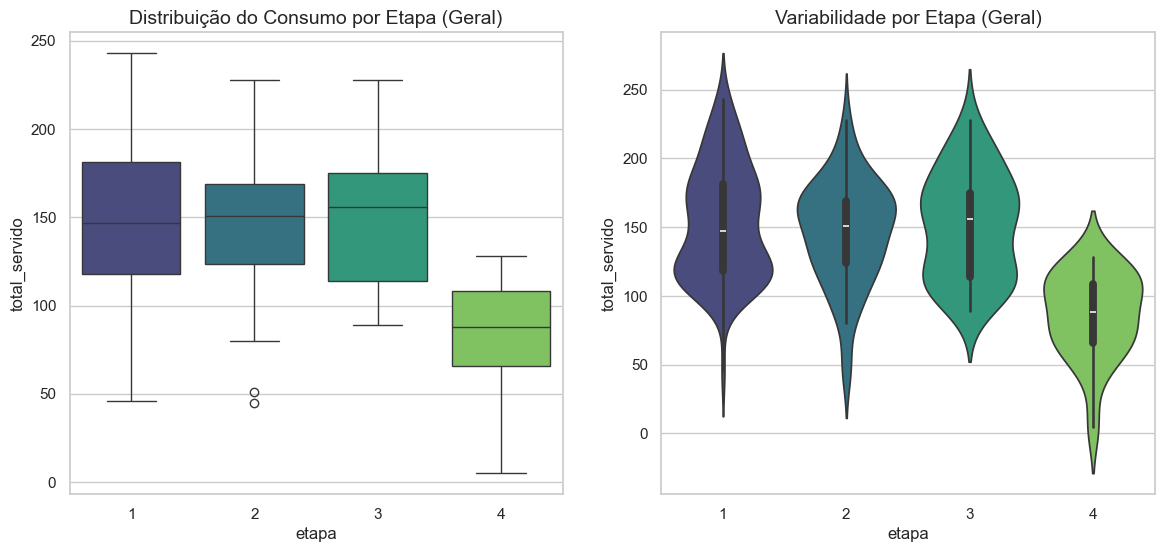

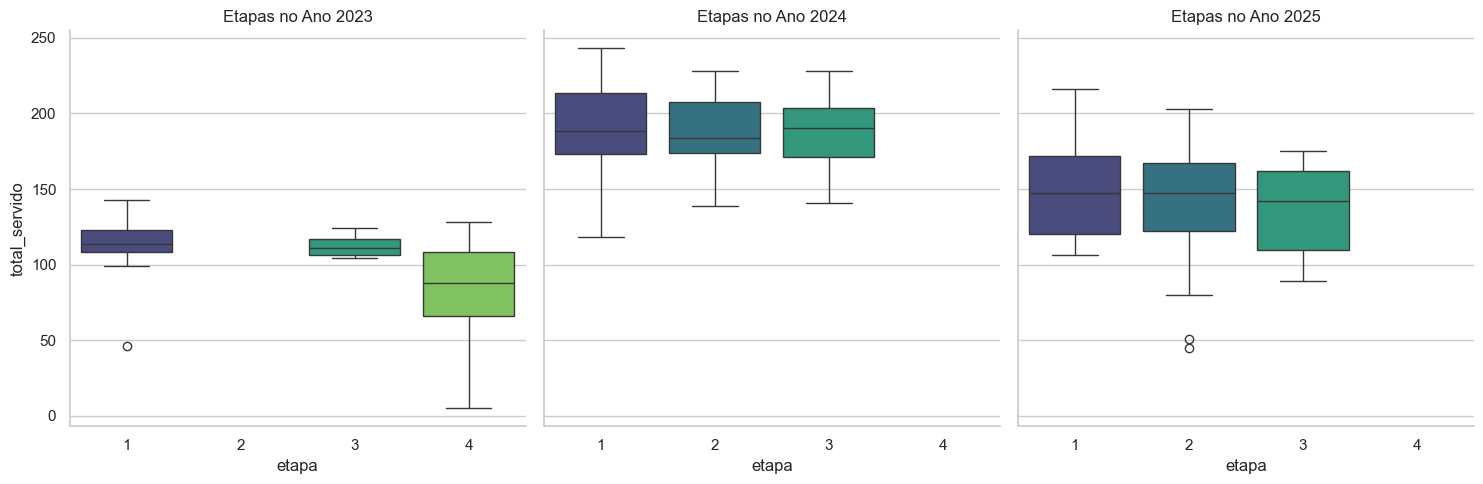

In [43]:
# 2.1 Visão Geral
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_ativo, x='etapa', y='total_servido', palette='viridis')
plt.title("Distribuição do Consumo por Etapa (Geral)")

plt.subplot(1, 2, 2)
sns.violinplot(data=df_ativo, x='etapa', y='total_servido', palette='viridis')
plt.title("Variabilidade por Etapa (Geral)")
plt.show()

# 2.2 Visão por Ano
g = sns.FacetGrid(df_ativo, col="ano", height=5, aspect=1)
g.map(sns.boxplot, "etapa", "total_servido", palette="viridis", order=[1,2,3,4])
g.set_titles("Etapas no Ano {col_name}")
plt.show()

## 3. Sazonalidade Trimestral e Mensal (Mapas de Calor)

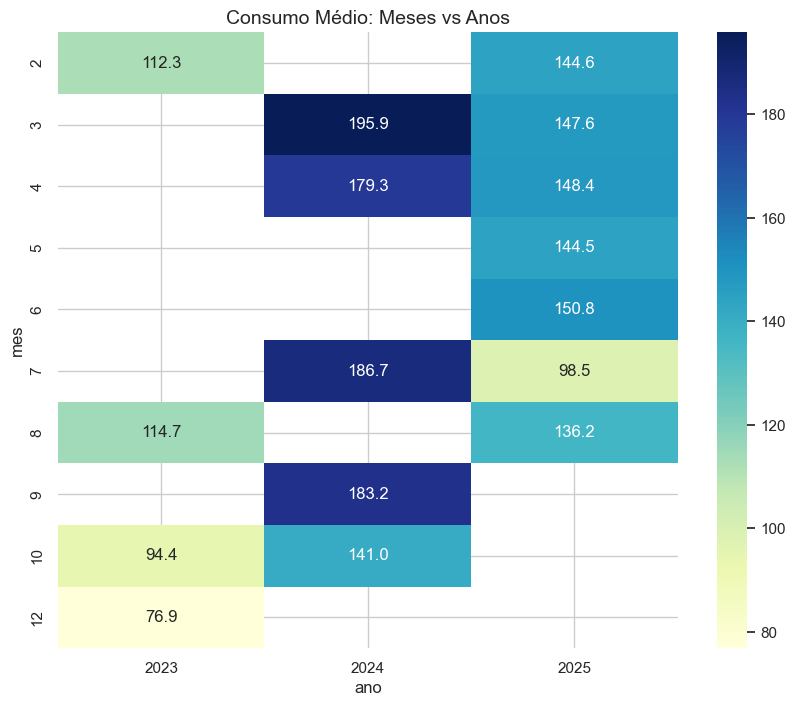

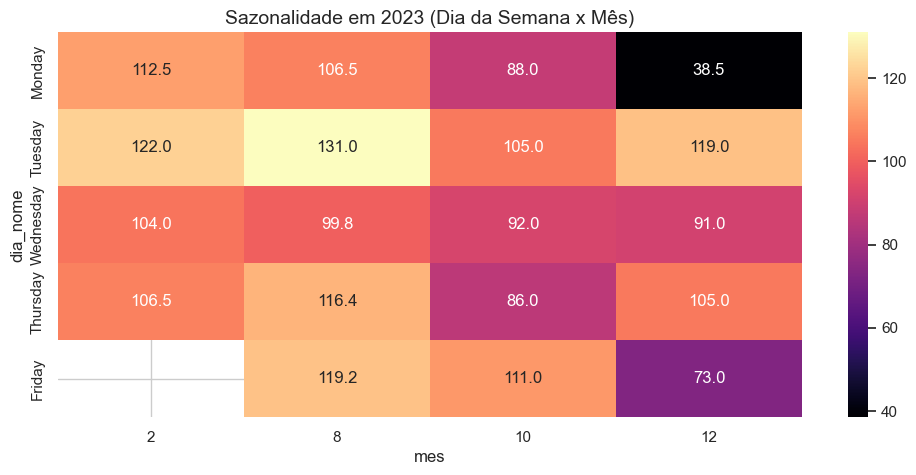

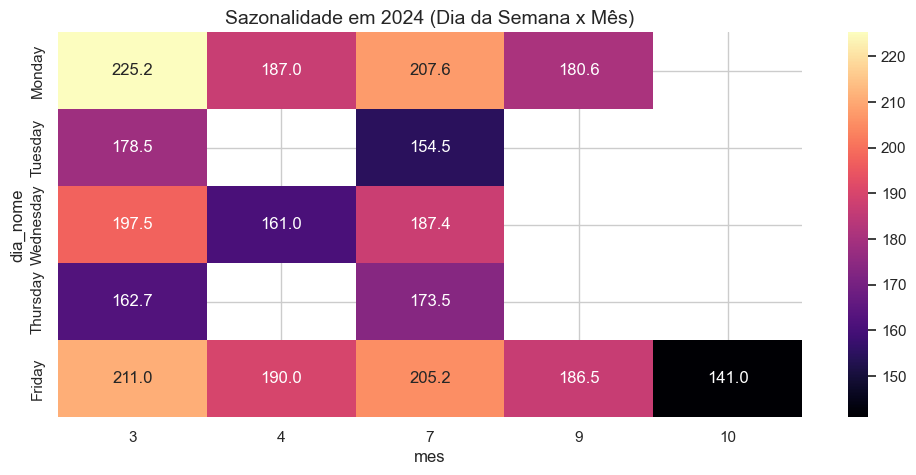

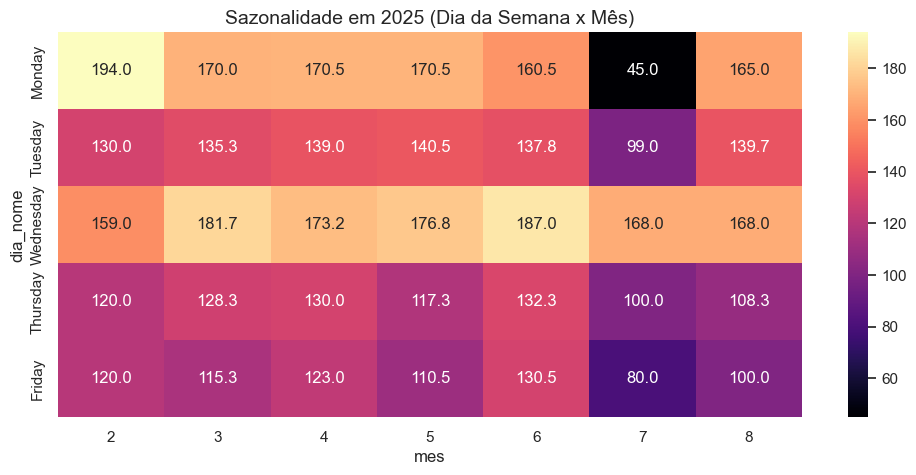

In [44]:
# 3.1 Visão Geral
pivot_all = df_ativo.pivot_table(values='total_servido', index='mes', columns='ano', aggfunc='mean')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_all, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Consumo Médio: Meses vs Anos")
plt.show()

# 3.2 Visão Detalhada por Ano
for ano in sorted(df_ativo['ano'].unique()):
    df_y = df_ativo[df_ativo['ano'] == ano].copy()
    df_y['dia_nome'] = df_y['data'].dt.day_name()
    order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    pivot_y = df_y.pivot_table(values='total_servido', index='dia_nome', columns='mes', aggfunc='mean').reindex(order_days)
    
    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_y, annot=True, fmt=".1f", cmap="magma")
    plt.title(f"Sazonalidade em {ano} (Dia da Semana x Mês)")
    plt.show()

## 4. Impacto de Eventos Especiais e Reuniões

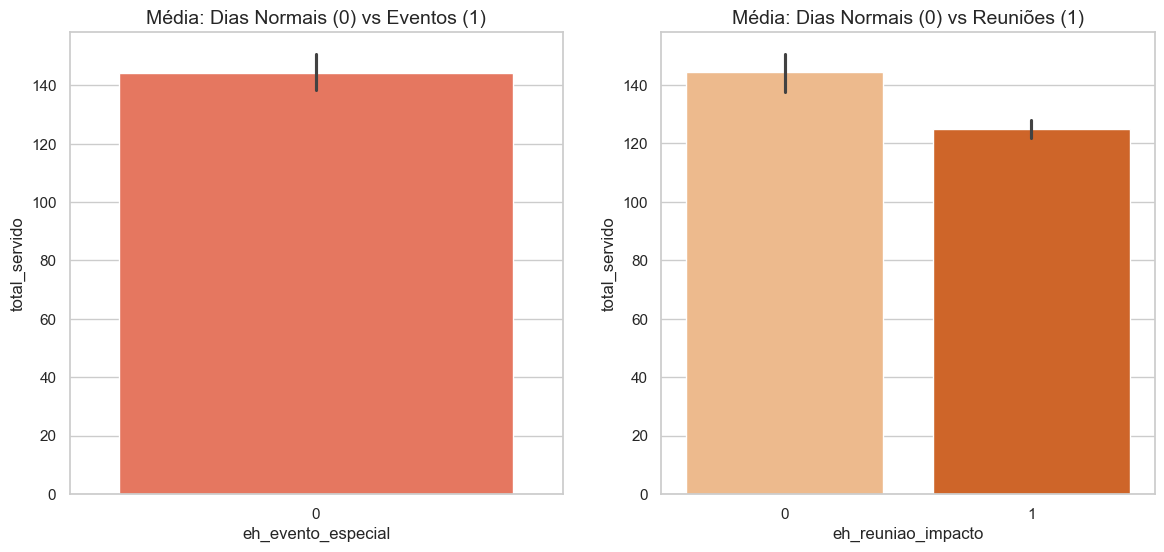

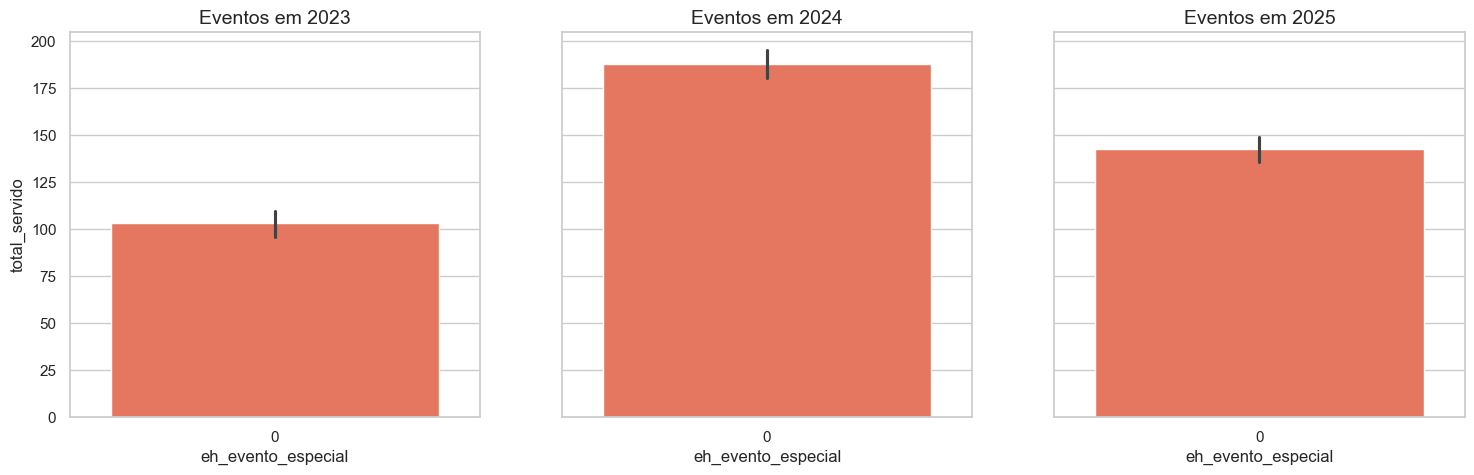

In [45]:
# 4.1 Impacto Geral
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=df_ativo, x='eh_evento_especial', y='total_servido', palette='Reds')
plt.title("Média: Dias Normais (0) vs Eventos (1)")

plt.subplot(1, 2, 2)
sns.barplot(data=df_ativo, x='eh_reuniao_impacto', y='total_servido', palette='Oranges')
plt.title("Média: Dias Normais (0) vs Reuniões (1)")
plt.show()

# 4.2 Impacto Detalhado por Ano
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, ano in enumerate(sorted(df_ativo['ano'].unique())):
    sns.barplot(data=df_ativo[df_ativo['ano']==ano], x='eh_evento_especial', y='total_servido', ax=axes[i], palette='Reds')
    axes[i].set_title(f"Eventos em {ano}")
plt.show()

## 5. Influência do Clima no Consumo

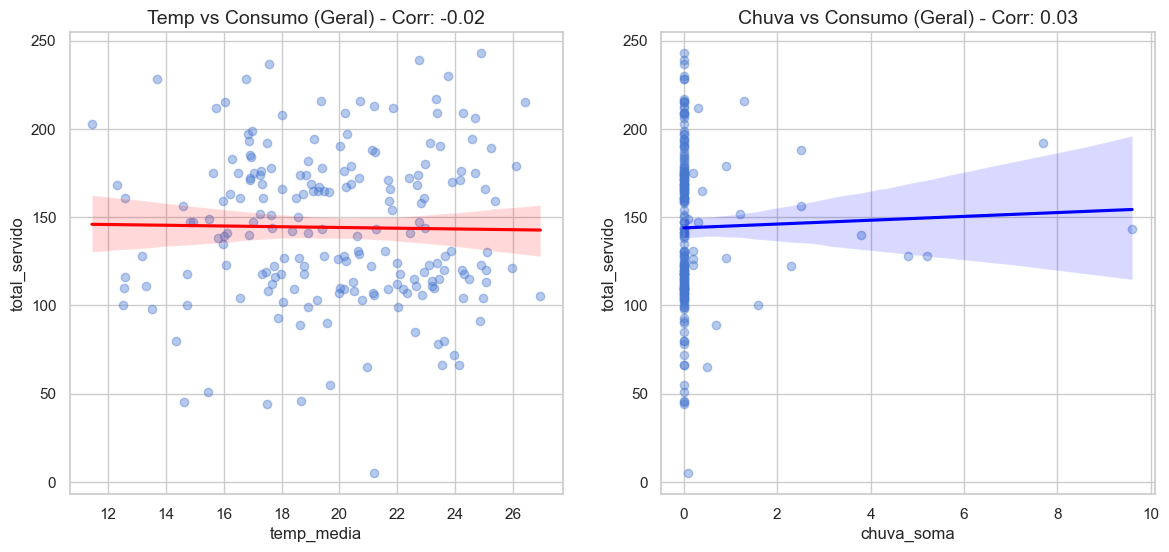

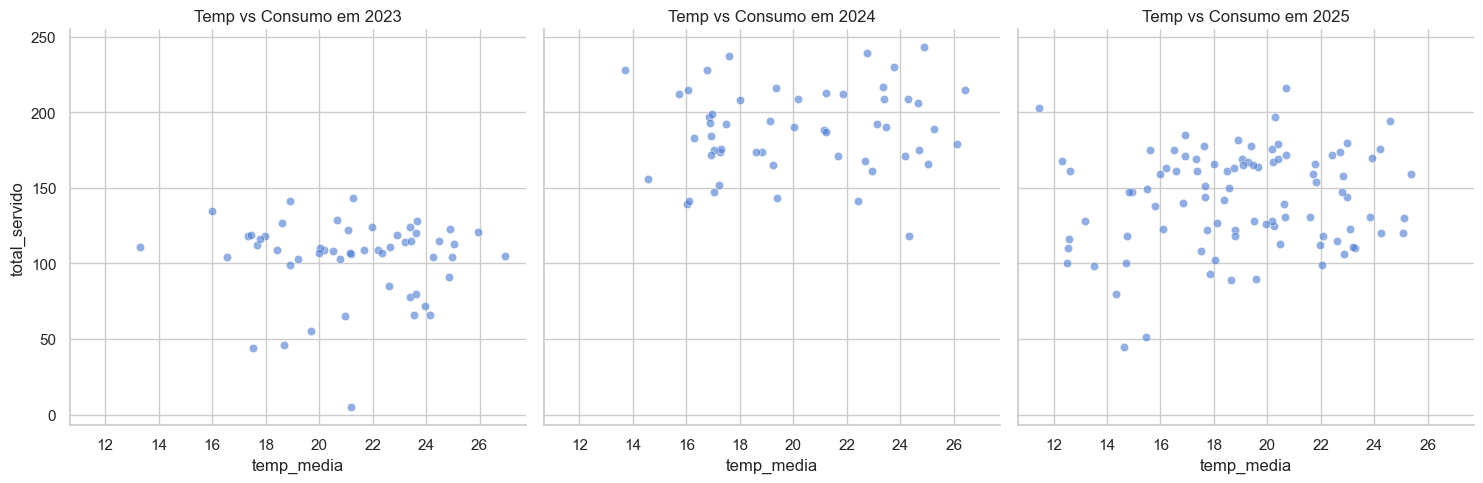

In [46]:
# 5.1 Correlação Geral
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.regplot(data=df_ativo, x='temp_media', y='total_servido', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title(f"Temp vs Consumo (Geral) - Corr: {df_ativo['temp_media'].corr(df_ativo['total_servido']):.2f}")

plt.subplot(1, 2, 2)
sns.regplot(data=df_ativo, x='chuva_soma', y='total_servido', scatter_kws={'alpha':0.4}, line_kws={'color':'blue'})
plt.title(f"Chuva vs Consumo (Geral) - Corr: {df_ativo['chuva_soma'].corr(df_ativo['total_servido']):.2f}")
plt.show()

# 5.2 Dispersão por Ano
g = sns.FacetGrid(df_ativo, col="ano", height=5, aspect=1)
g.map(sns.scatterplot, "temp_media", "total_servido", alpha=0.6)
g.set_titles("Temp vs Consumo em {col_name}")
plt.show()

## 6. Precisão do Planejamento: Reservas vs Consumo Real

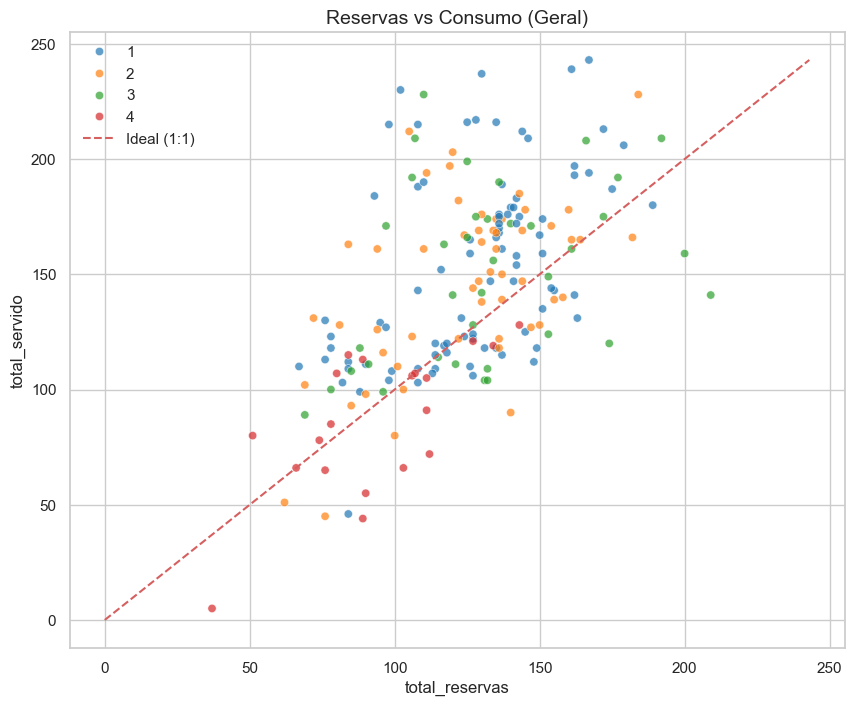

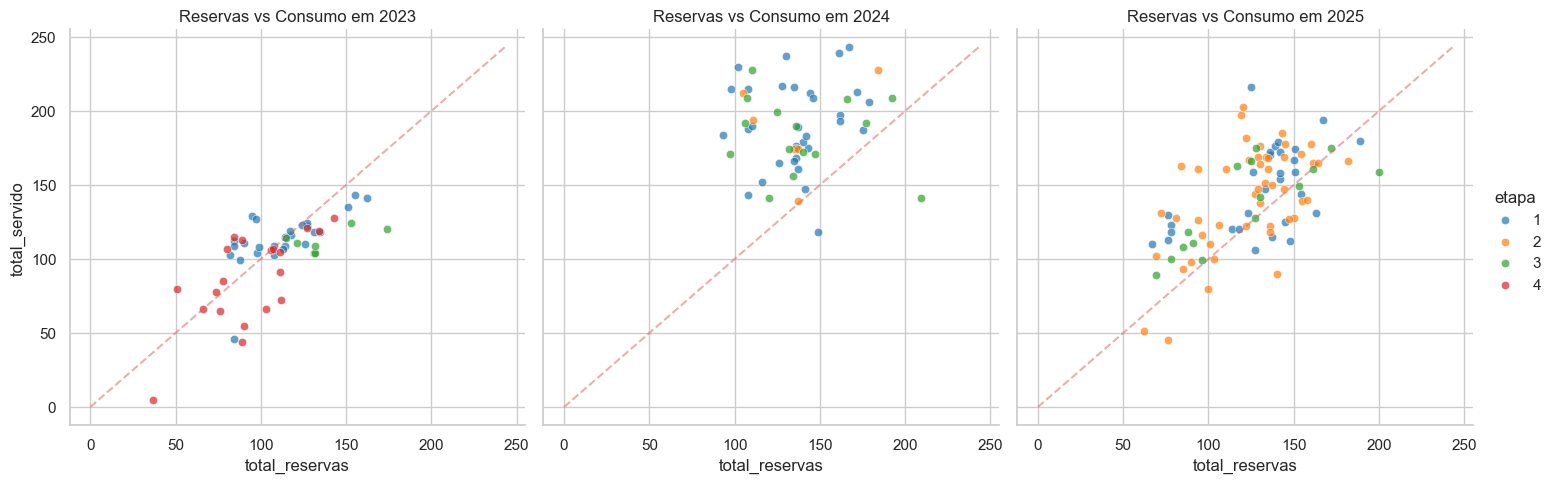

In [47]:
# 6.1 Visão Geral
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_ativo, x='total_reservas', y='total_servido', hue='etapa', palette='tab10', alpha=0.7)
max_val = max(df_ativo['total_reservas'].max(), df_ativo['total_servido'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal (1:1)')
plt.title("Reservas vs Consumo (Geral)")
plt.legend()
plt.show()

# 6.2 Visão por Ano
g = sns.FacetGrid(df_ativo, col="ano", hue="etapa", palette="tab10", height=5, aspect=1)
g.map(sns.scatterplot, "total_reservas", "total_servido", alpha=0.7)
for ax in g.axes.flat:
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5)
g.add_legend()
g.set_titles("Reservas vs Consumo em {col_name}")
plt.show()

## 7. Impacto do Cardápio no Consumo (Geral e por Ano)
Análise da influência da Proteína Principal e do Tipo de Preparo.

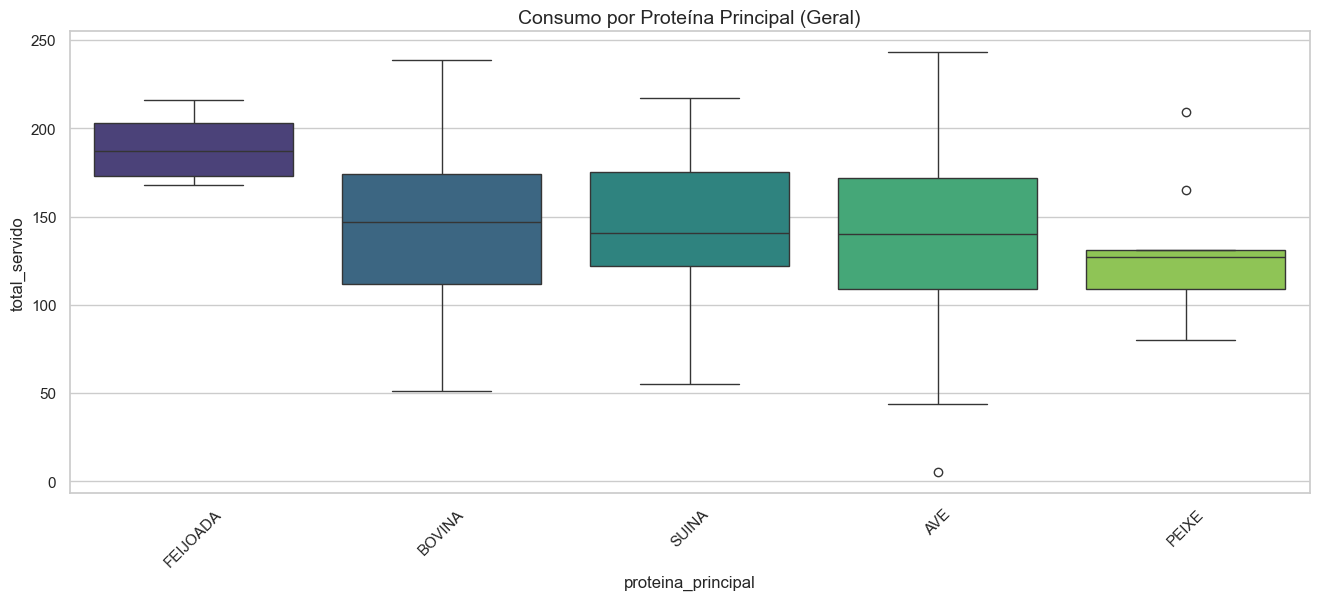

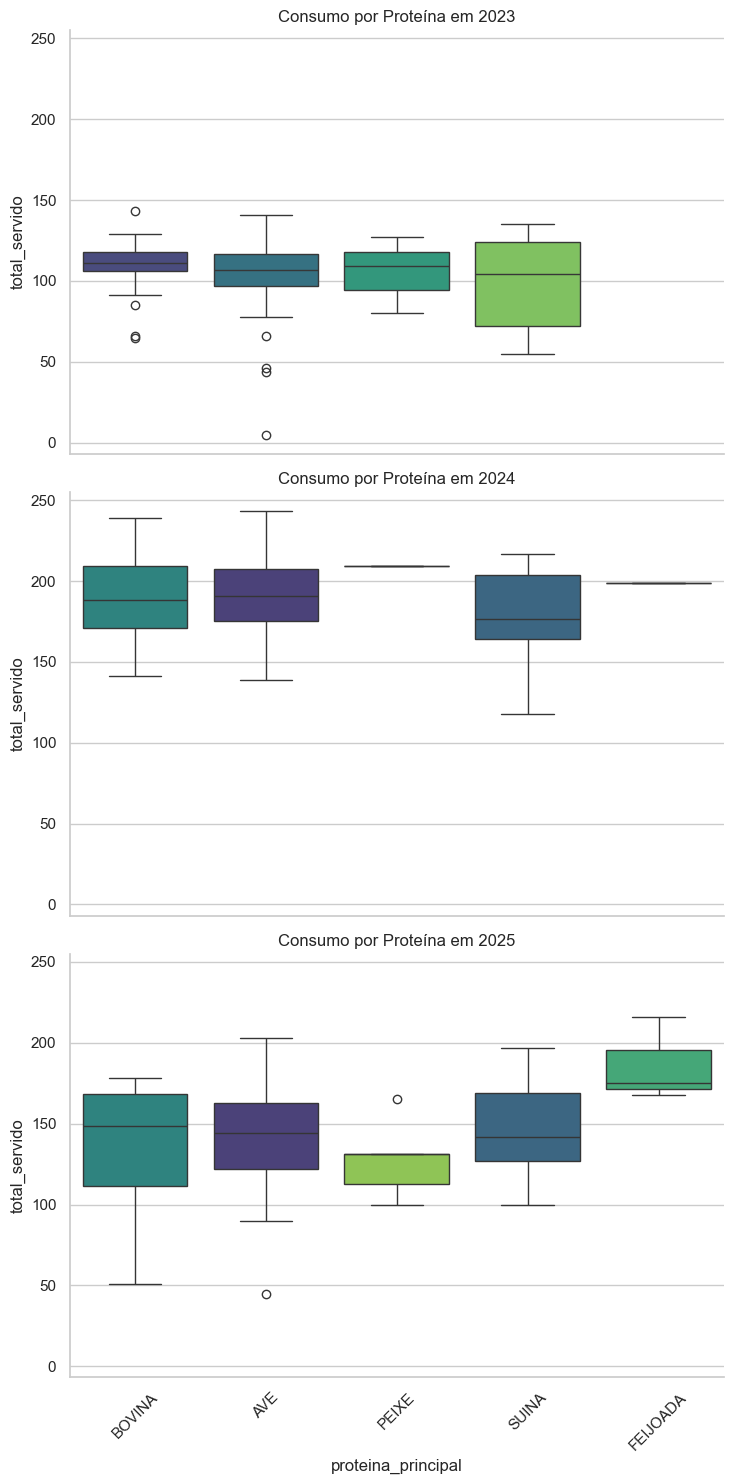

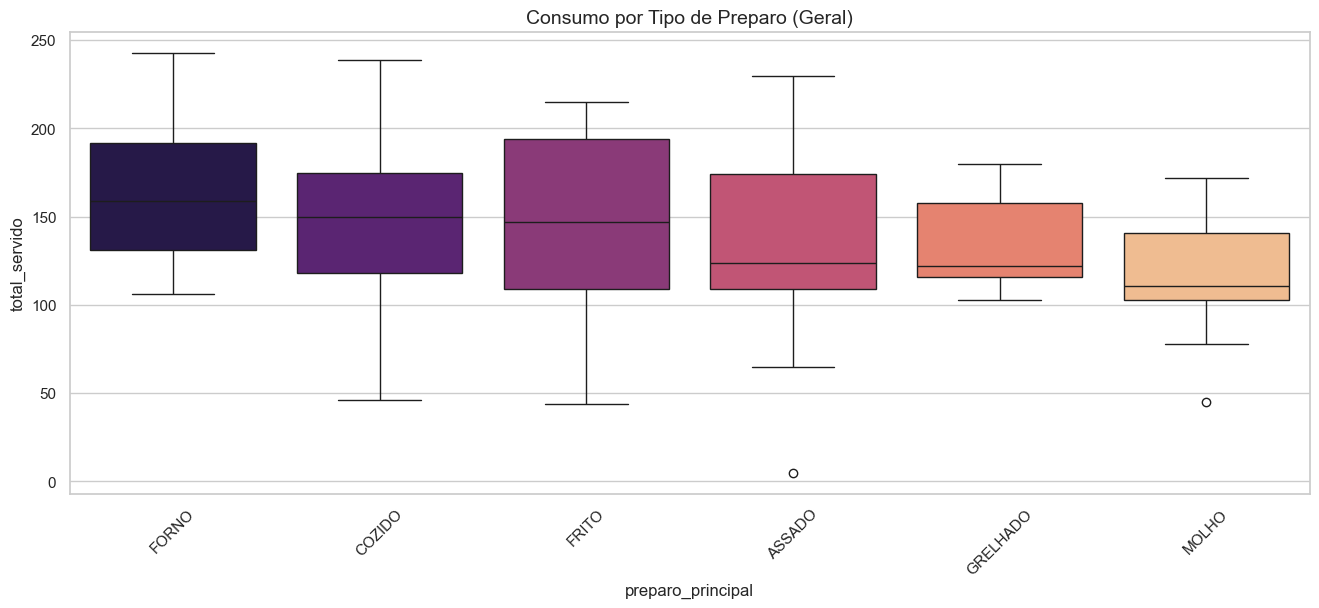

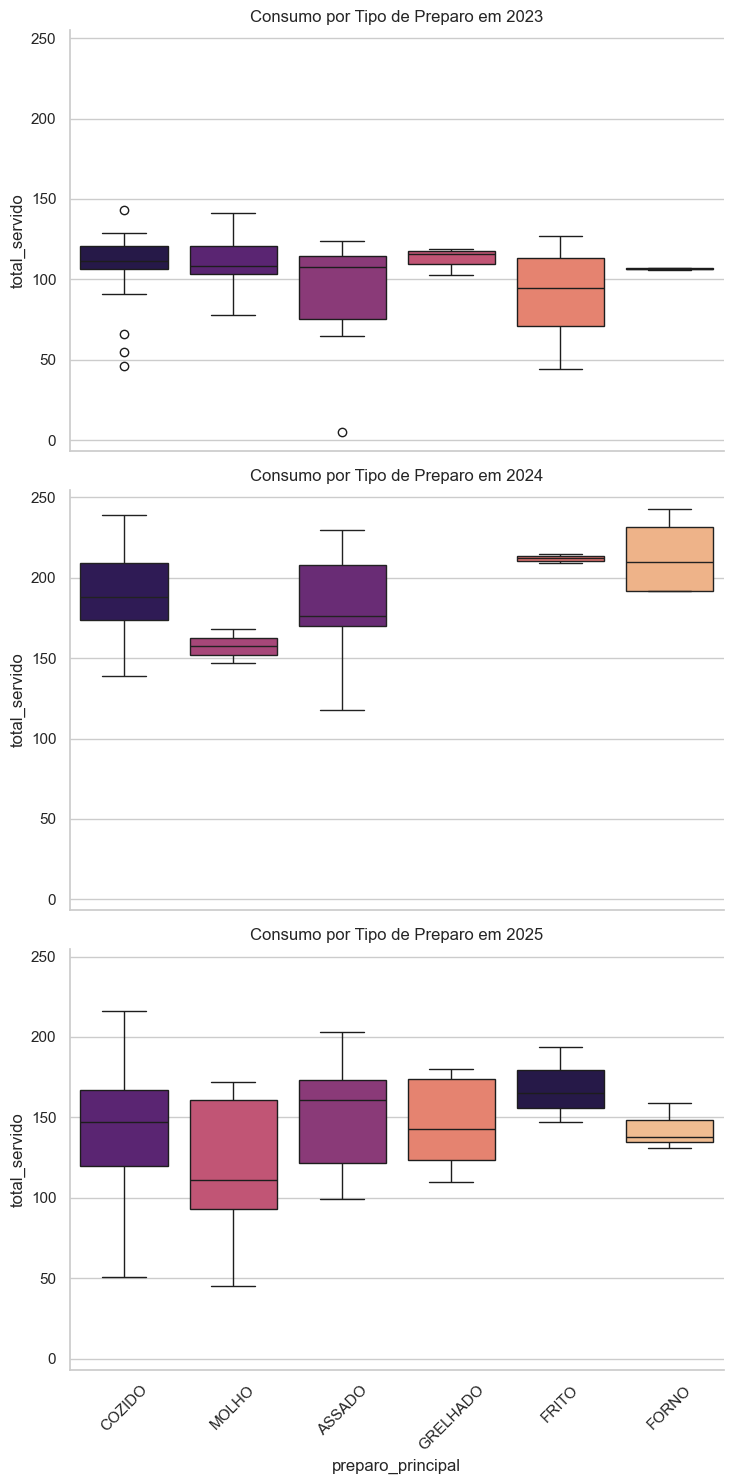

In [48]:
# 7.1 Proteína Principal (Visão Geral)
plt.figure(figsize=(16, 6))
order_prot = df_ativo.groupby('proteina_principal')['total_servido'].median().sort_values(ascending=False).index
sns.boxplot(data=df_ativo, x='proteina_principal', y='total_servido', order=order_prot, palette='viridis')
plt.title("Consumo por Proteína Principal (Geral)")
plt.xticks(rotation=45)
plt.show()

# 7.2 Proteína Principal POR ANO
g = sns.FacetGrid(df_ativo, col="ano", height=5, aspect=1.5, col_wrap=1)
g.map_dataframe(sns.boxplot, x="proteina_principal", y="total_servido", palette="viridis")
g.set_titles("Consumo por Proteína em {col_name}")
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
plt.tight_layout()
plt.show()

# 7.3 Preparo Principal (Visão Geral)
plt.figure(figsize=(16, 6))
order_prep = df_ativo.groupby('preparo_principal')['total_servido'].median().sort_values(ascending=False).index
sns.boxplot(data=df_ativo, x='preparo_principal', y='total_servido', order=order_prep, palette='magma')
plt.title("Consumo por Tipo de Preparo (Geral)")
plt.xticks(rotation=45)
plt.show()

# 7.4 Preparo Principal POR ANO
g = sns.FacetGrid(df_ativo, col="ano", height=5, aspect=1.5, col_wrap=1)
g.map_dataframe(sns.boxplot, x="preparo_principal", y="total_servido", palette="magma")
g.set_titles("Consumo por Tipo de Preparo em {col_name}")
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
plt.tight_layout()
plt.show()

## 8. Linha do Tempo: Evolução e Dias Atípicos

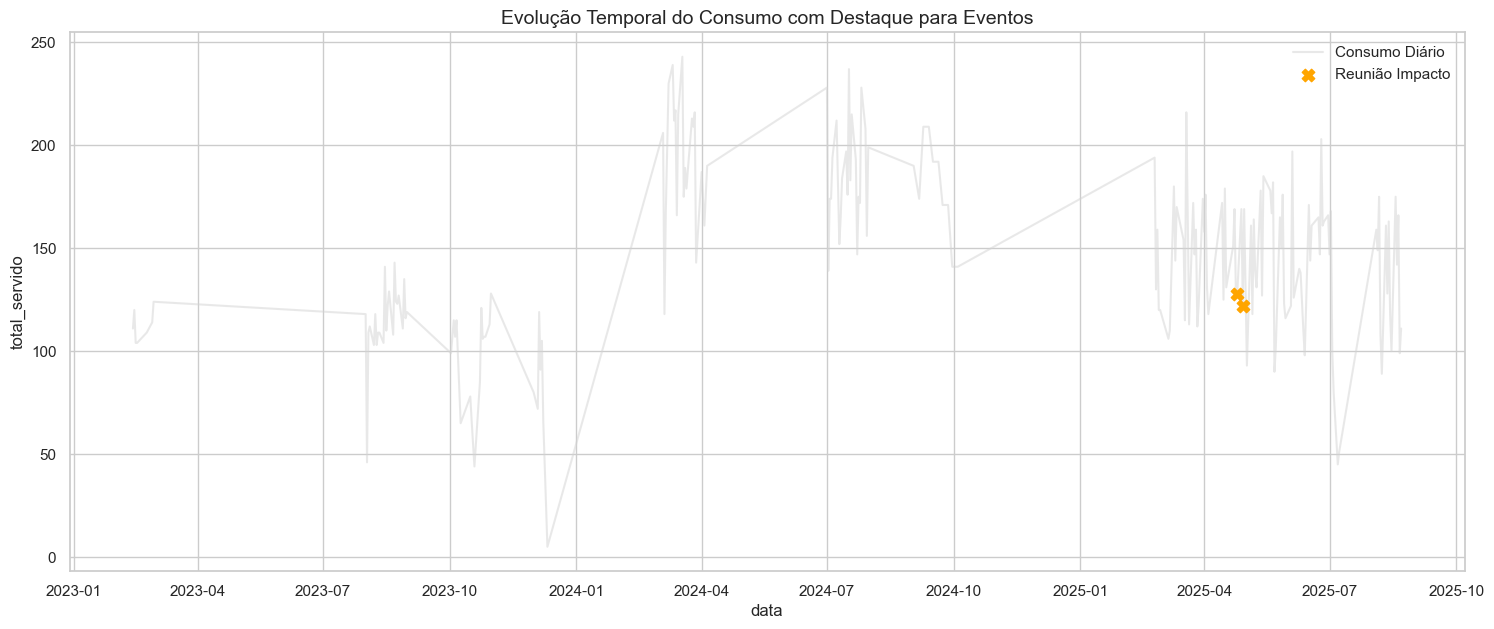

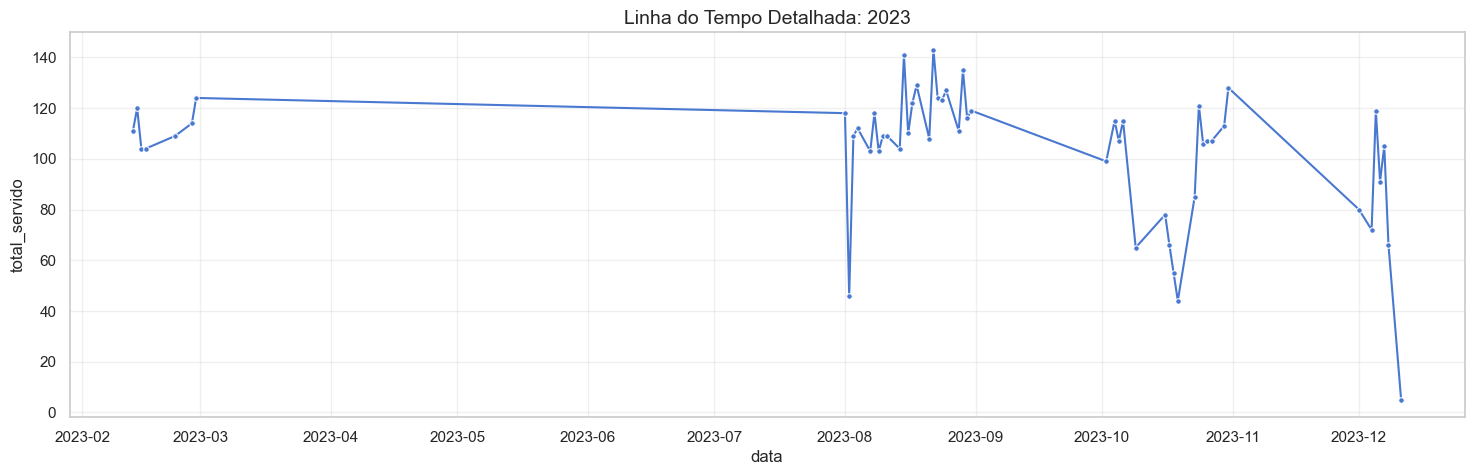

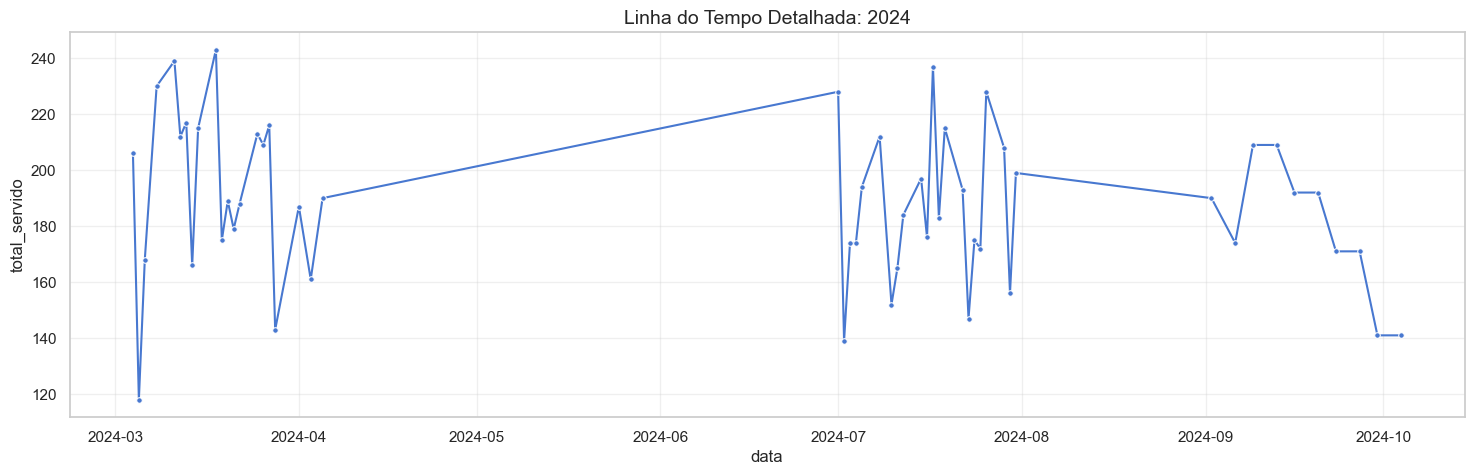

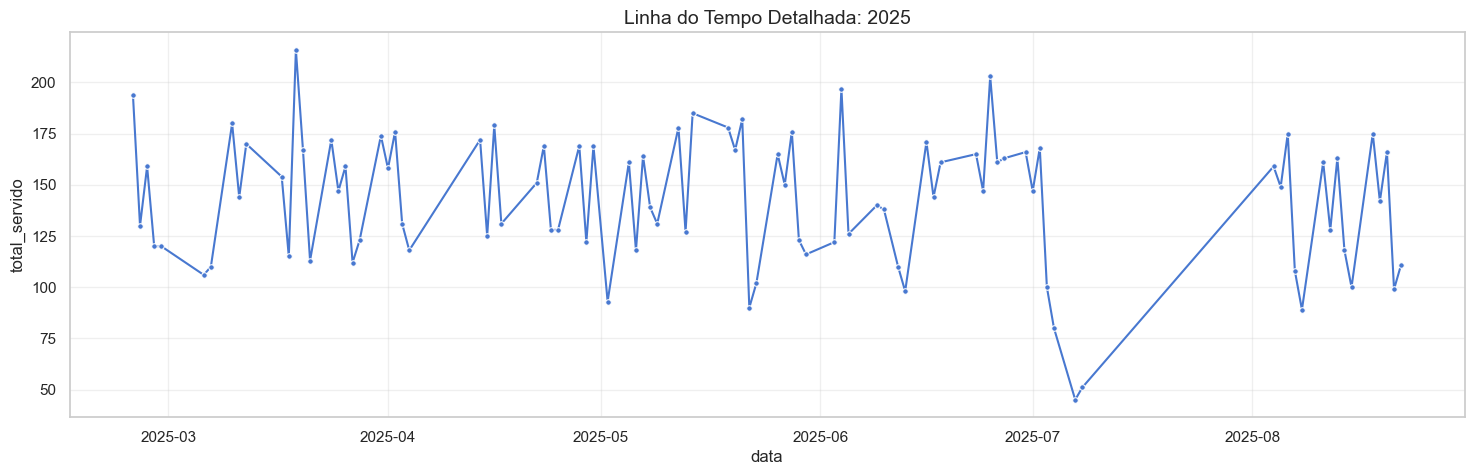

In [49]:
# 8.1 Linha do Tempo Completa
plt.figure(figsize=(18, 7))
sns.lineplot(data=df_ativo, x='data', y='total_servido', color='lightgray', alpha=0.5, label='Consumo Diário')
eventos = df_ativo[df_ativo['eh_evento_especial'] == 1]
reunioes = df_ativo[df_ativo['eh_reuniao_impacto'] == 1]

if not eventos.empty:
    plt.scatter(eventos['data'], eventos['total_servido'], color='red', s=100, label='Evento Especial', zorder=5)
if not reunioes.empty:
    plt.scatter(reunioes['data'], reunioes['total_servido'], color='orange', s=80, marker='X', label='Reunião Impacto', zorder=5)

plt.title("Evolução Temporal do Consumo com Destaque para Eventos")
plt.legend()
plt.show()

# 8.2 Zooms Anuais
for ano in sorted(df_ativo['ano'].unique()):
    df_year = df_ativo[df_ativo['ano'] == ano]
    plt.figure(figsize=(18, 5))
    sns.lineplot(data=df_year, x='data', y='total_servido', marker='o', markersize=4)
    ev_y = df_year[df_year['eh_evento_especial'] == 1]
    if not ev_y.empty:
        plt.scatter(ev_y['data'], ev_y['total_servido'], color='red', s=100, zorder=5)
    plt.title(f"Linha do Tempo Detalhada: {ano}")
    plt.grid(True, alpha=0.3)
    plt.show()